## In this problem, you will perform K-means clustering manually, with K = 2, on a small example with n = 6 observations and p = 2 features. 

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

## (a) Plot the observations.

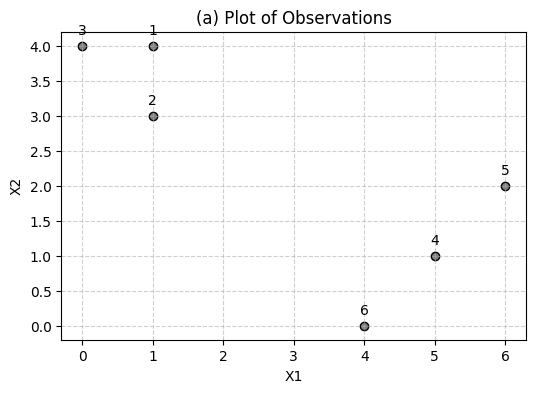

In [3]:
data = pd.DataFrame({
    'Observation': [1, 2, 3, 4, 5, 6],
    'X1': [1, 1, 0, 5, 6, 4],
    'X2': [4, 3, 4, 1, 2, 0]
})

plt.figure(figsize=(6, 4))
plt.scatter(data['X1'], data['X2'], color='gray', edgecolor='black')
for i, txt in enumerate(data['Observation']):
    plt.annotate(txt, (data['X1'][i], data['X2'][i]), textcoords="offset points", xytext=(0, 8), ha='center')
plt.title('(a) Plot of Observations')
plt.xlabel('X1')
plt.ylabel('X2')
plt.grid(True, linestyle="--", alpha=0.6)
plt.show()

(b) Randomly assign a cluster label to each observation. You can use the np.random.choice() function to do this. Report the cluster labels for each observation.

In [4]:
np.random.seed(1)  # 固定隨機種子，結果可重現
data['Cluster'] = np.random.choice([0, 1], size=len(data))
print("(b) Initial Random Cluster Assignments:")
print(data[['Observation', 'Cluster']], '\n')

(b) Initial Random Cluster Assignments:
   Observation  Cluster
0            1        1
1            2        1
2            3        0
3            4        0
4            5        1
5            6        1 



### (c) Compute the centroid for each cluster.

In [7]:
centroids = data.groupby("Cluster")[["X1", "X2"]].mean()
print("(c) Initial Cluster Centroids:")
print(centroids, '\n')

(c) Initial Cluster Centroids:
          X1    X2
Cluster           
0        2.5  2.50
1        3.0  2.25 



### (d) Assign each observation to the centroid to which it is closest, in terms of Euclidean distance. Report the cluster labels for each observation.

In [8]:
def assign_clusters(df, centroids):
    new_labels = []
    for i in range(len(df)):
        x, y = df.loc[i, ["X1", "X2"]]
        # 計算到每個 centroid 的距離
        dists = centroids.apply(lambda row: np.sqrt((x - row.X1)**2 + (y - row.X2)**2), axis=1)
        new_labels.append(dists.idxmin())
    return new_labels

data['New_cluster'] = assign_clusters(data, centroids)
print("(d) Re-assigned Cluster Labels:")
print(data[['Observation', 'Cluster', 'New_cluster']], '\n')

(d) Re-assigned Cluster Labels:
   Observation  Cluster  New_cluster
0            1        1            0
1            2        1            0
2            3        0            0
3            4        0            1
4            5        1            1
5            6        1            1 



### (e) Repeat (c) and (d) until the answers obtained stop changing.

In [9]:
while True:
    centroids = data.groupby("New_cluster")[["X1", "X2"]].mean()
    new_labels = assign_clusters(data, centroids)
    if all(data["New_cluster"] == new_labels):
        break
    data["New_cluster"] = new_labels

print("(e) Final Centroids After Convergence:")
print(centroids, '\n')
print("Final Cluster Assignments:")
print(data[['Observation', 'X1', 'X2', 'New_cluster']], '\n')

(e) Final Centroids After Convergence:
                   X1        X2
New_cluster                    
0            0.666667  3.666667
1            5.000000  1.000000 

Final Cluster Assignments:
   Observation  X1  X2  New_cluster
0            1   1   4            0
1            2   1   3            0
2            3   0   4            0
3            4   5   1            1
4            5   6   2            1
5            6   4   0            1 



### (f) In your plot from (a), color the observations according to the cluster labels obtained.

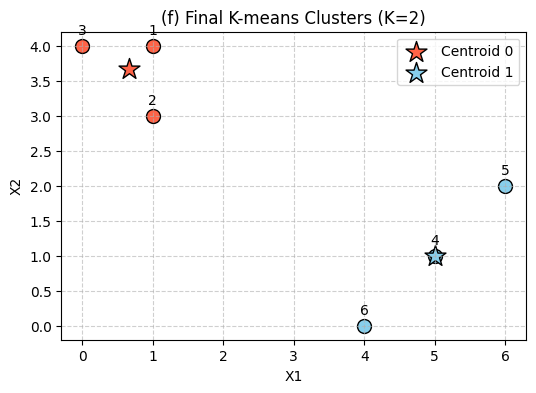

In [10]:
colors = {0: "tomato", 1: "skyblue"}

plt.figure(figsize=(6, 4))
for _, row in data.iterrows():
    plt.scatter(row['X1'], row['X2'],
                color=colors[int(row['New_cluster'])],
                edgecolor="black", s=100)
    plt.annotate(int(row['Observation']),
                 (row['X1'], row['X2']),
                 textcoords="offset points", xytext=(0, 8), ha='center')

# 畫出中心點
for cluster, row in centroids.iterrows():
    plt.scatter(row['X1'], row['X2'],
                marker="*", s=250,
                color=colors[cluster], edgecolor="black",
                label=f"Centroid {cluster}")

plt.title('(f) Final K-means Clusters (K=2)')
plt.xlabel('X1')
plt.ylabel('X2')
plt.legend()
plt.grid(True, linestyle="--", alpha=0.6)
plt.show()